# Basic Example using MOGPTK

Fit a multi-output spectral mixture GP to a simple two-band example. Bands are similar sinusoids but with a known phase difference plus some Gaussian noise.

In [1]:
import mogptk
import torch
import numpy as np
import matplotlib.pyplot as plt

#torch.manual_seed(0);

/home/scf/repos/mogptk-examples/.venv/lib/python3.14/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


The MOSM kernel has the form (Definition 5; Parra & Tobar 2017):

$$k_{ij}(\tau) = \sum_{q=1}^Q \alpha^{(q)}_{ij} \exp \left( -\frac{1}{2} (\tau + \theta^{(q)}_{ij})^\top \Sigma^{(q)}_{ij}(\tau + \theta^{(q)}_{ij}) \right) \cos \left( (\tau + \theta^{(q)}_{ij})^\top \mu^{(q)}_{ij} + \phi^{(q)}_{ij} \right), \qquad \alpha^{(q)}_{ij} = w^{(q)}_{ij} (2\pi)^{n/2} | \Sigma^{(q)}_{ij} |^{1/2} $$

- No. of spectral mixture components: $Q$
- parameter of $q$ th mixture component: $(.)^{(q)}$
- Covariance: $\Sigma_{ij}$
- Mean: $\mu_{ij}$
- Magnitude (weight of component): $w_{ij}$
- Delay: $\theta_{ij} = \theta_i - \theta_j$
- Phase: $\phi_{ij} = \phi_i - \phi_j$

**NB:** the above parameters describe the shape of the kernel in the *spectral* domain.

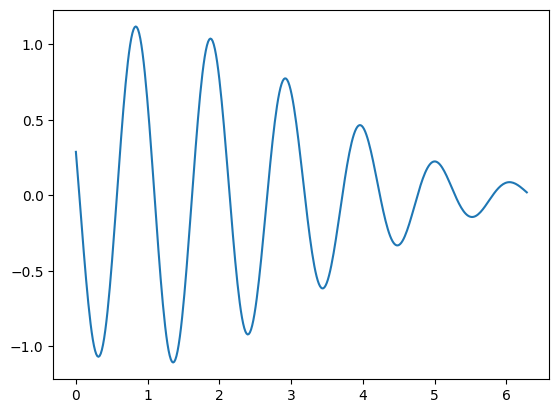

In [2]:
# Plot one-dimensional, single-component MOSM kernel in time domain
def plot_k(taus, w_mag, sigma_cov, theta_delay, mu_freq, phi_phase):
    alpha = w_mag * (2*np.pi)**0.5 * np.abs(sigma_cov)**0.5
    k = alpha*np.exp(-0.5*(taus+theta_delay)**2*sigma_cov) * np.cos( (taus+theta_delay)*mu_freq + phi_phase)

    plt.plot(taus, k)

taus = np.linspace(0, 2*np.pi, 400)
plot_k(taus, w_mag=1, sigma_cov=1/5, theta_delay=-1, mu_freq=6, phi_phase=1)

For a MOSM GP with a single mixture component (Q = 1), the $i^\mathrm{th}$ diagonal submatrix corresponding to the $i^\mathrm{th}$ band ($i = j$, $\theta_{ii} = 0$, $\phi_{ii} = 0$) is a SE $\times$ cosine autocovariance kernel:

$$k_{ii}(\tau) = \alpha_{ii} \exp\left\{ -\frac{1}{2} \tau^\top \Sigma_{ii} \tau \right\} \cos(\tau^\top \mu_{ii})$$

where $\alpha$ is an amplitude and $\Sigma$ is a length-scale hyperparameter.

Between bands 1 and 2, the kernel is:

$$k_{12}(\tau) = \alpha_{12} \exp \left\{ -\frac{1}{2} (\tau + \theta_{12})^\top \Sigma_{12} (\tau + \theta_{12}) \right\} \cos\left((\tau + \theta_{12})^\top \mu_{12} + \phi_{12}\right)$$

$$\alpha_{12} = w_{12} (2\pi)^\frac{n}{2} |\Sigma_{12}|^\frac{1}{2}$$

## Two-band: Phase shifted

### Synthetic dataset

- Two noisy sinusoidal signals:
    - same frequency, $f = 0.7$ cycles/s, or $\omega = 2\pi \times 0.7 = 1.4\pi$ radians/s,
    - same amplitude $A = 2.0$, 
    - second band is phase shifted by $\varphi = 0.4$ radians.
- Both bands with added Gaussian noise ($\sigma_\varepsilon = 0.25$).
- Both bands with 20\% of data points removed randomly.

$$Y_1 \mid t \sim \mathcal{N}\left(A \sin(\omega t), \sigma_\varepsilon^2\right)$$

$$Y_2 \mid t \sim \mathcal{N}\left(A \sin(\omega t + \varphi), \sigma_\varepsilon^2\right)$$

or

$$Y_2 \mid t \sim \mathcal{N}\left(A \sin \left(\omega \left[t + \frac{\varphi}{\omega}\right] \right), \sigma_\varepsilon^2\right)$$

Expect to see the second waveform shifted backwards in time by $\frac{\varphi}{\omega}$.

Cross-covariance between bands 1 and 2 if $\theta_{12} = 0$:

$$k_{12}(\tau) = \alpha_{12} \exp \left\{ -\frac{1}{2} \Sigma_{12} \tau^2 \right\} \cos\left(\mu_{12}\tau + \phi_{12}\right)$$

and if $\phi_{12} = 0$:


$$k_{12}(\tau) = \alpha_{12} \exp \left\{ -\frac{1}{2} \Sigma_{12} (\tau + \theta_{12})^2 \right\} \cos\left( \mu_{12}(\tau + \theta_{12})\right)$$

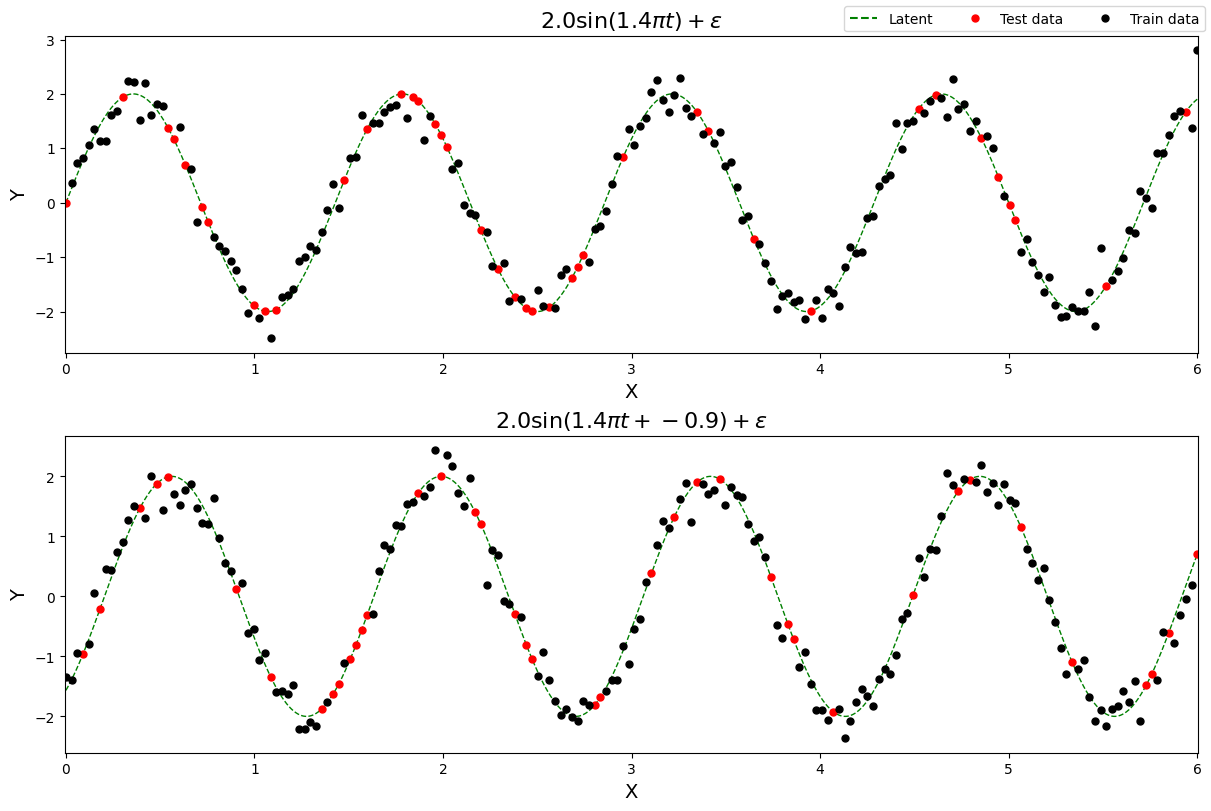

In [3]:
n_points = 200
amplitude = 2.0
noise_sigma = 0.25

frequency = 0.7 # cycles/s
period = 1/frequency # seconds
omega = 2*np.pi*frequency # radians/s
phase_shift = -0.9 # radians

t = np.linspace(0.0, 6, n_points) # seconds

f1 = amplitude * np.sin(omega * t)
y1 = f1 + noise_sigma*np.random.normal(size=len(t))

f2 = amplitude * np.sin(omega * t + phase_shift) 
y2 = f2 + noise_sigma*np.random.normal(size=len(t))

dataset1 = mogptk.DataSet(
    mogptk.Data(t, y1, name=rf'${amplitude} \sin({2*frequency}\pi t) + \varepsilon$'),
    mogptk.Data(t, y2, name=rf'${amplitude} \sin({2*frequency}\pi t + {phase_shift}) + \varepsilon$')
)

dataset1[0].set_function(lambda t: amplitude * np.sin(omega * t) )
dataset1[1].set_function(lambda t: amplitude * np.sin(omega * t + phase_shift) )

for data in dataset1:
    data.remove_randomly(pct=0.2)

dataset1.plot();

### Power Spectrum

Knowing the mathematical expression for the synthetic data, we see the expected peak at $f = 0.5$ in the periodogram.

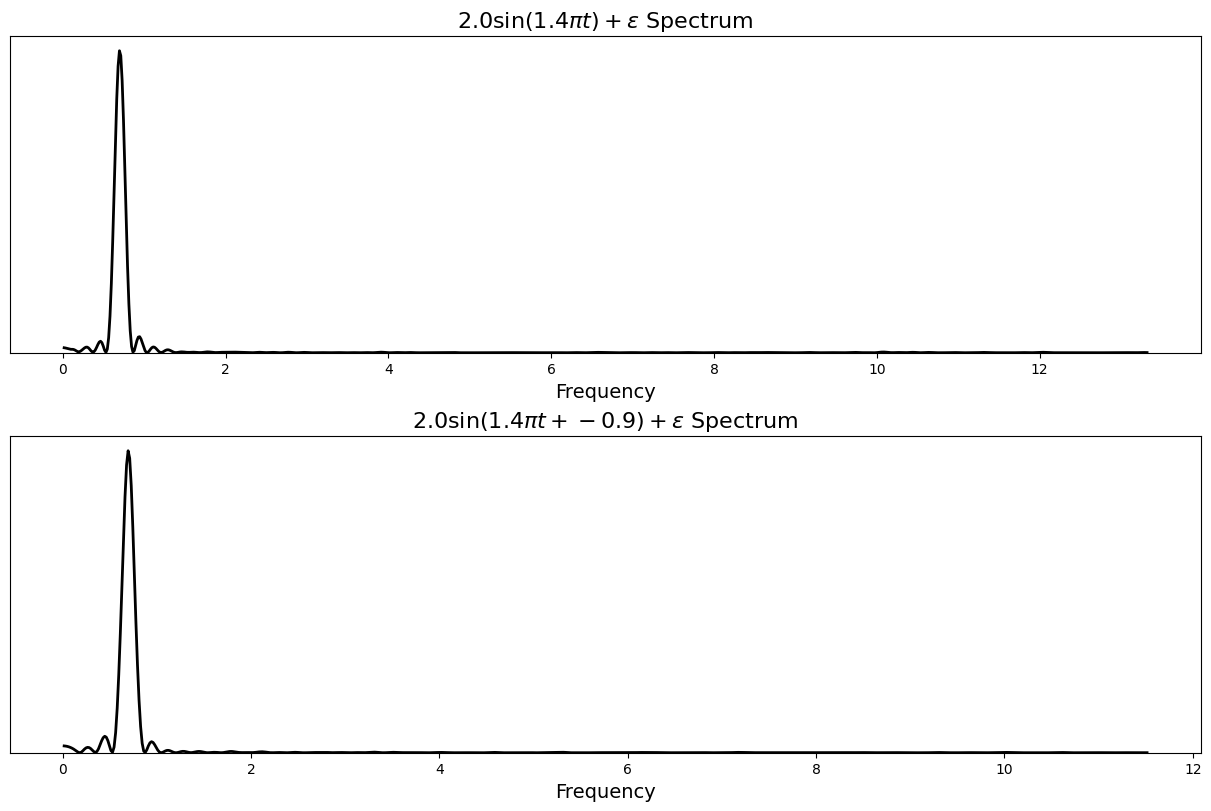

In [4]:
dataset1.plot_spectrum(method='ls'); # Lomb Scargle

## MOSM Model

### No initialisation

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[0.62216465] [0.37613474]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 16.583333333333627]",[[[1.e-08]] [[1.e-08]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.76765178]] [[0.57980917]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[0.]] [[0.]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[0.] [0.]]
GaussianLikelihood.scale,"[1e-08, ∞)",[1.0000001 1.0000001]


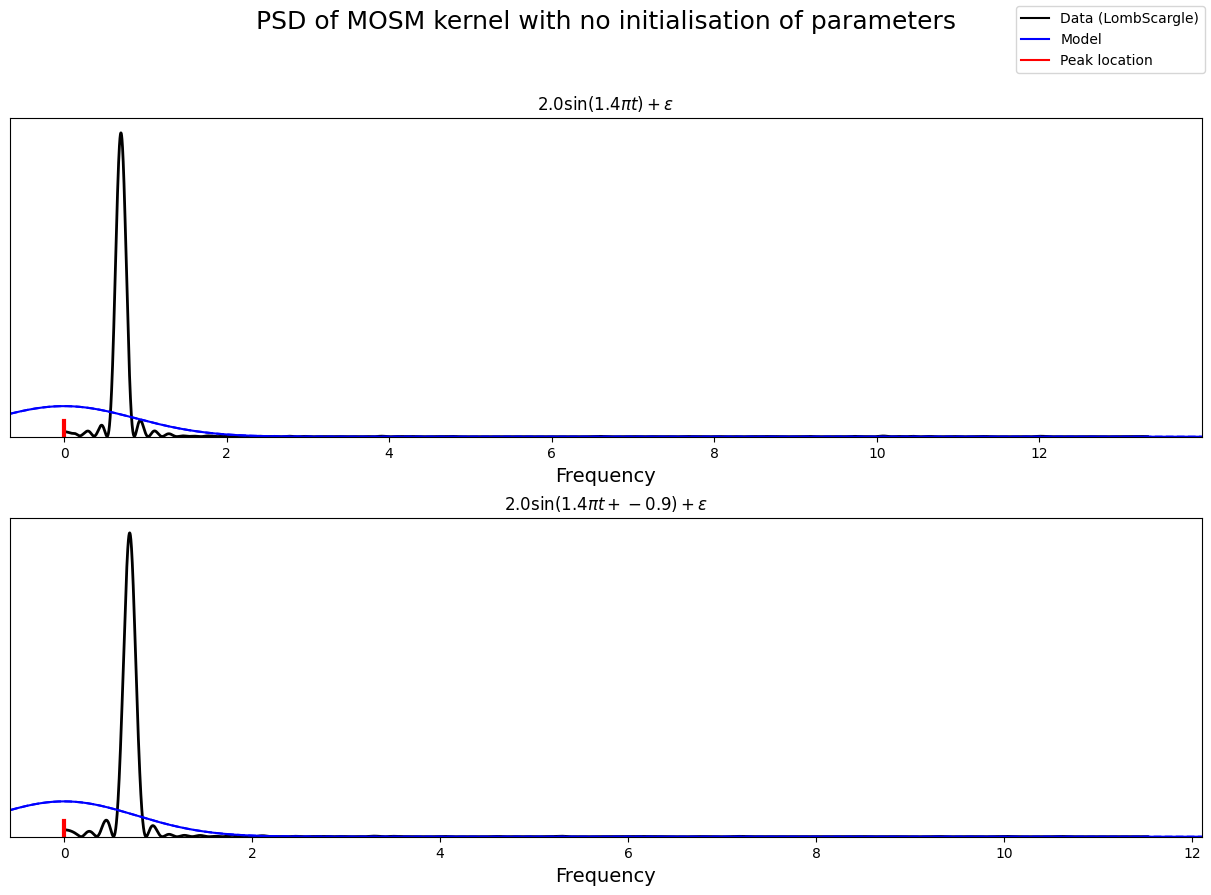

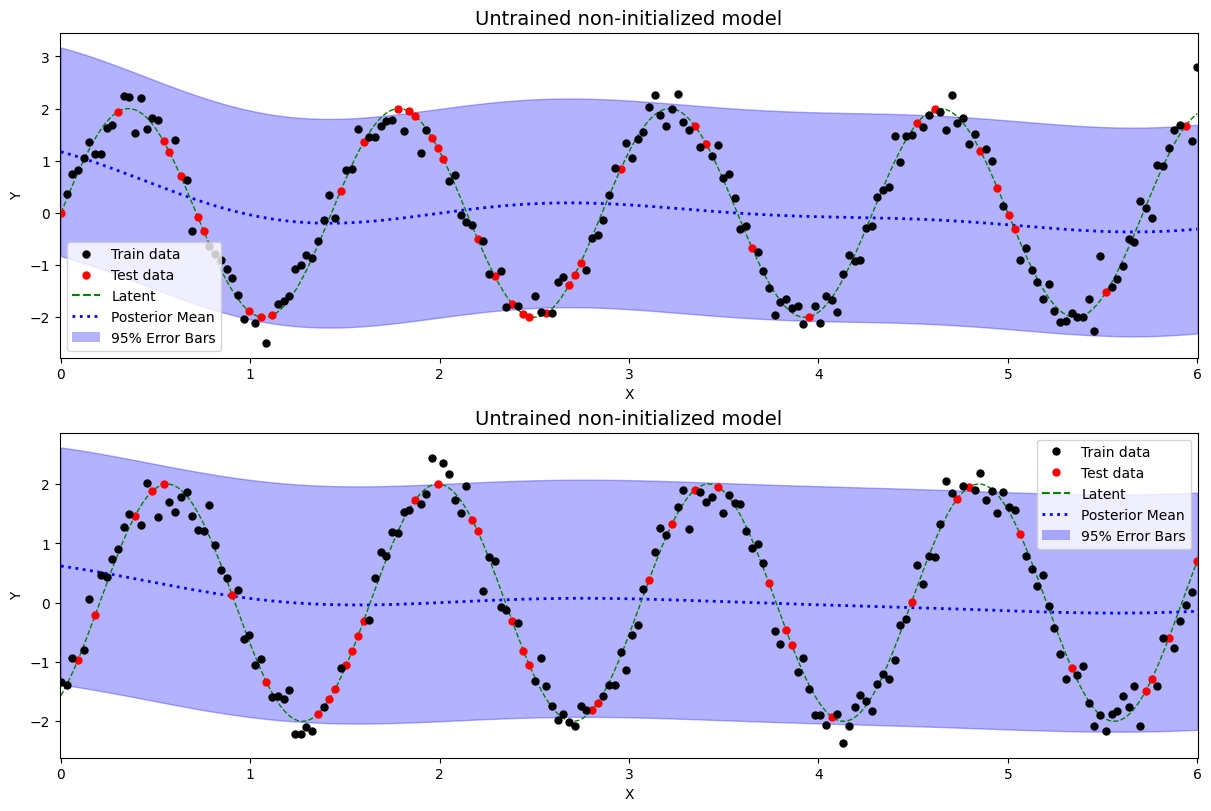

In [5]:
model1 = mogptk.MOSM(dataset1, Q=1)
model1.print_parameters()
model1.plot_spectrum(title='PSD of MOSM kernel with no initialisation of parameters');
model1.plot_prediction(title='Untrained non-initialized model');

### Model initialisation

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[19.54707682] [19.82172858]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 16.583333333333627]",[[[0.69988666]] [[0.69822816]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.00372289]] [[0.00398762]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[0.]] [[0.]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[0.] [0.]]
GaussianLikelihood.scale,"[1e-08, ∞)",[1.40469098 1.42292934]


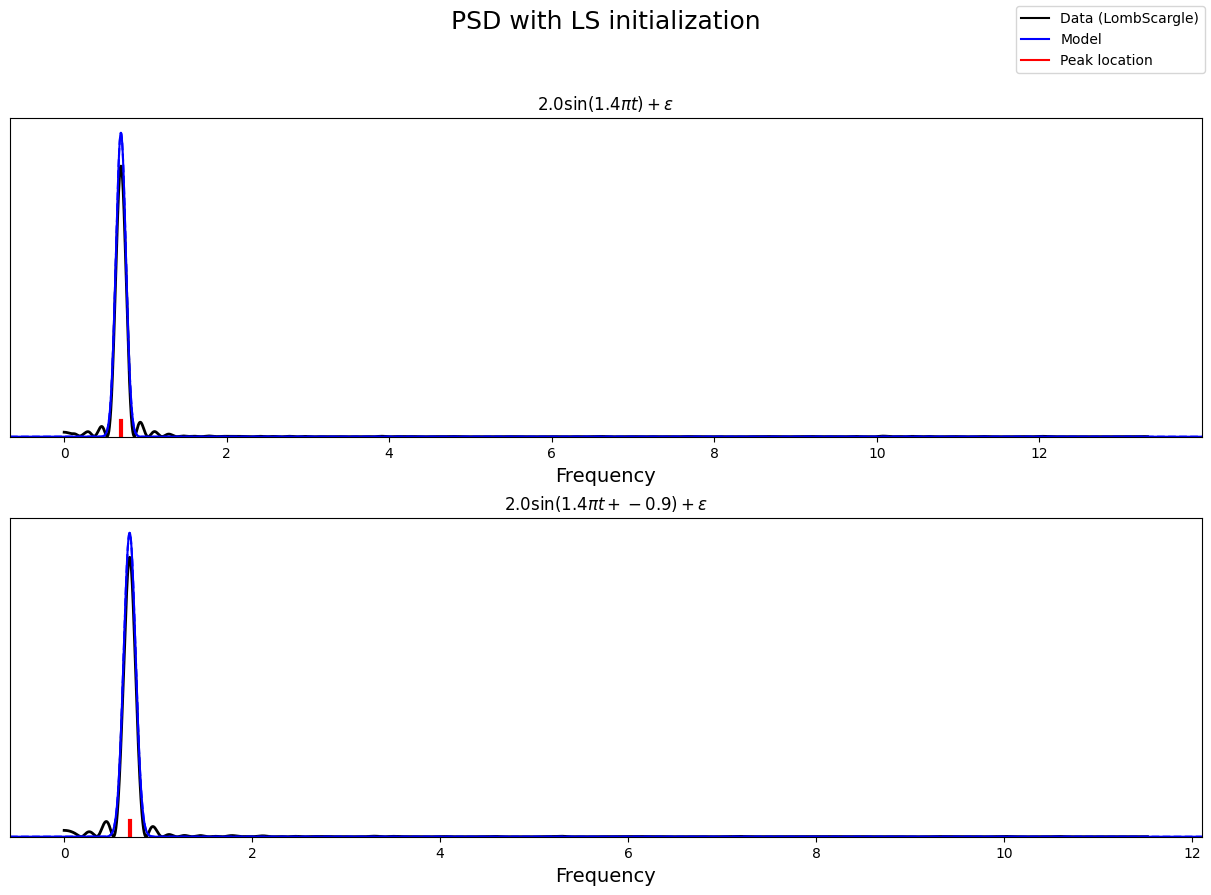

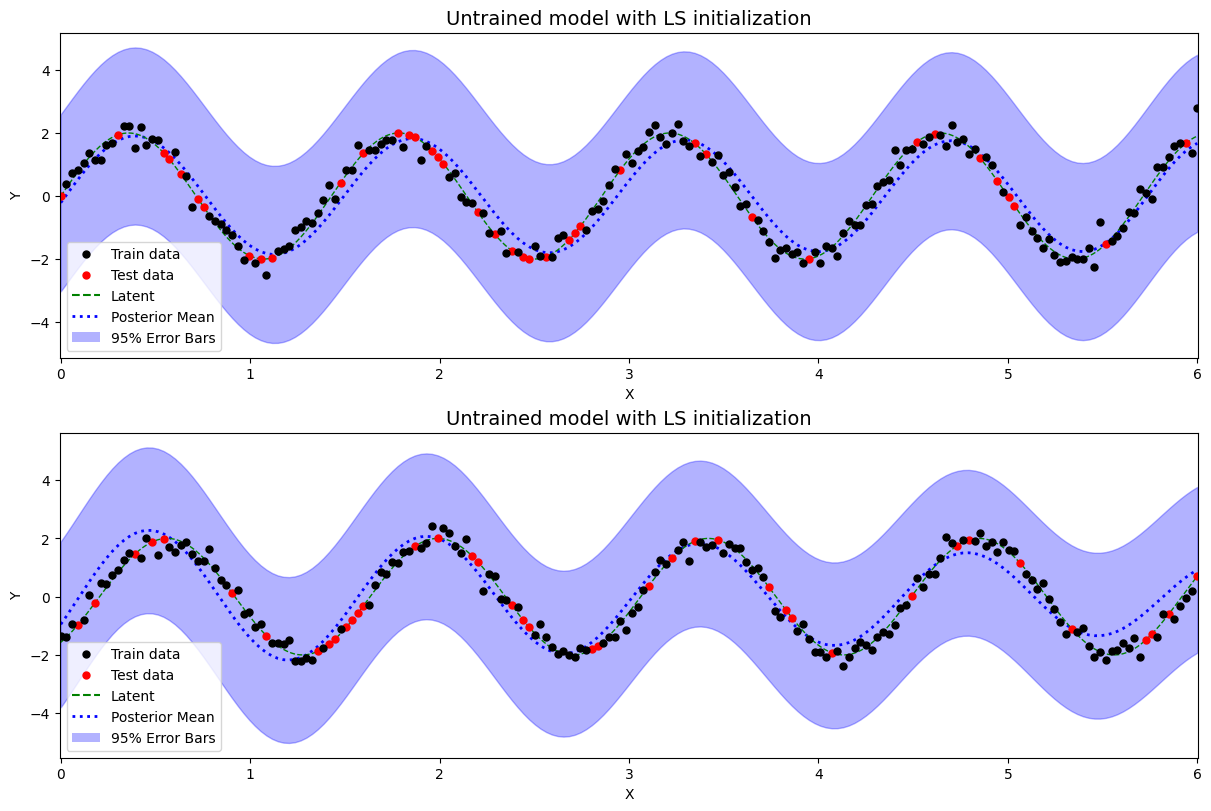

In [6]:
model2 = mogptk.MOSM(dataset1, Q=1)
model2.init_parameters(method='LS', iters=500)
model2.print_parameters()
model2.plot_spectrum(title='PSD with LS initialization');
model2.plot_prediction(title='Untrained model with LS initialization');

### Train model on data

Starting optimization using Adam
‣ Model: Exact
  ‣ Kernel: MultiOutputSpectralMixtureKernel
  ‣ Likelihood: GaussianLikelihood
‣ Channels: 2
‣ Parameters: 12
‣ Training points: 320
‣ Iterations: 1000


/home/scf/repos/mogptk-examples/.venv/lib/python3.14/site-packages/mogptk/model.py:384: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return float(self.gpr.loss())


     0/1000   0:00:00  loss=     442.269  error=    0.371005 (warmup)
  1000/1000   0:00:07  loss=     393.936  error=   0.0373794
Optimization finished in 7.702 seconds


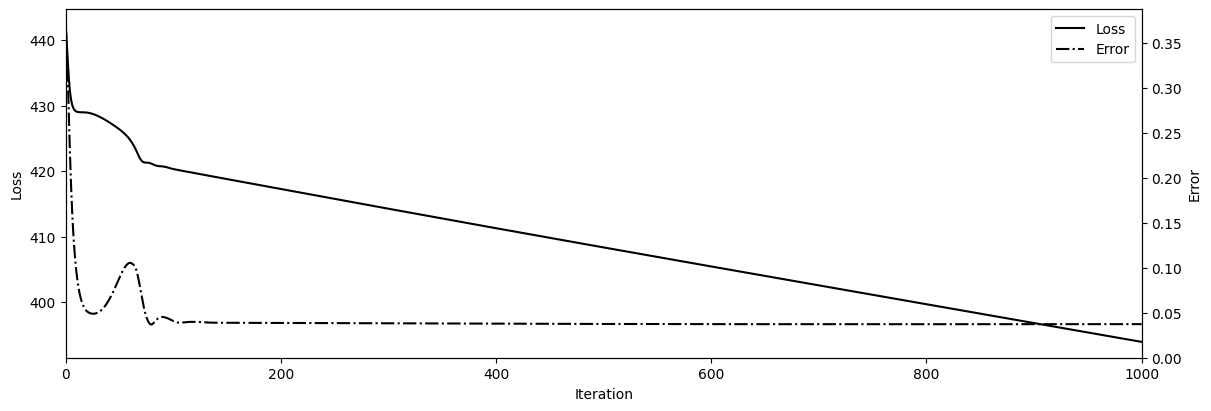

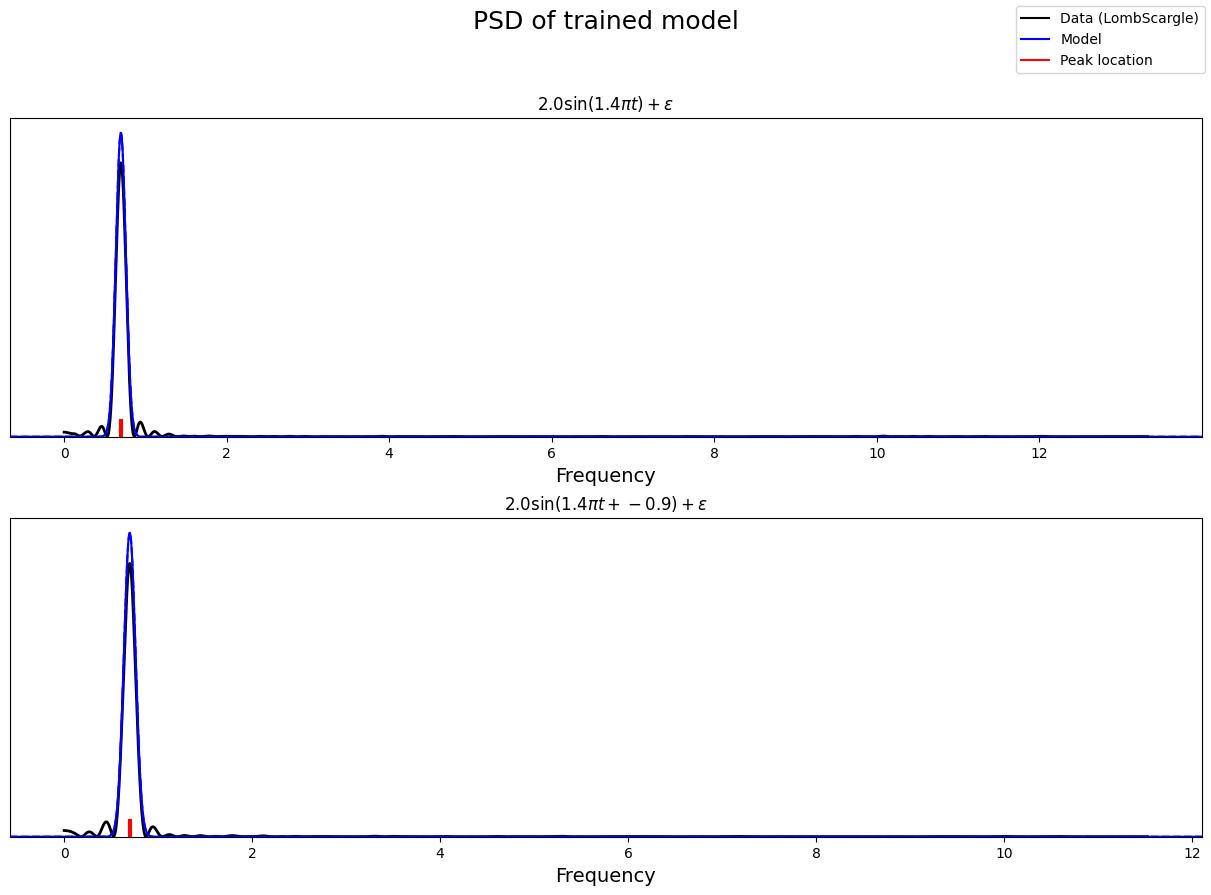

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[18.76284476] [19.02932439]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 16.583333333333627]",[[[0.69928408]] [[0.69926243]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.00381291]] [[0.00381417]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[ 0.04010161]] [[-0.04010161]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[ 0.04307769] [-0.04307769]]
GaussianLikelihood.scale,"[1e-08, ∞)",[1.27885887 1.29544587]


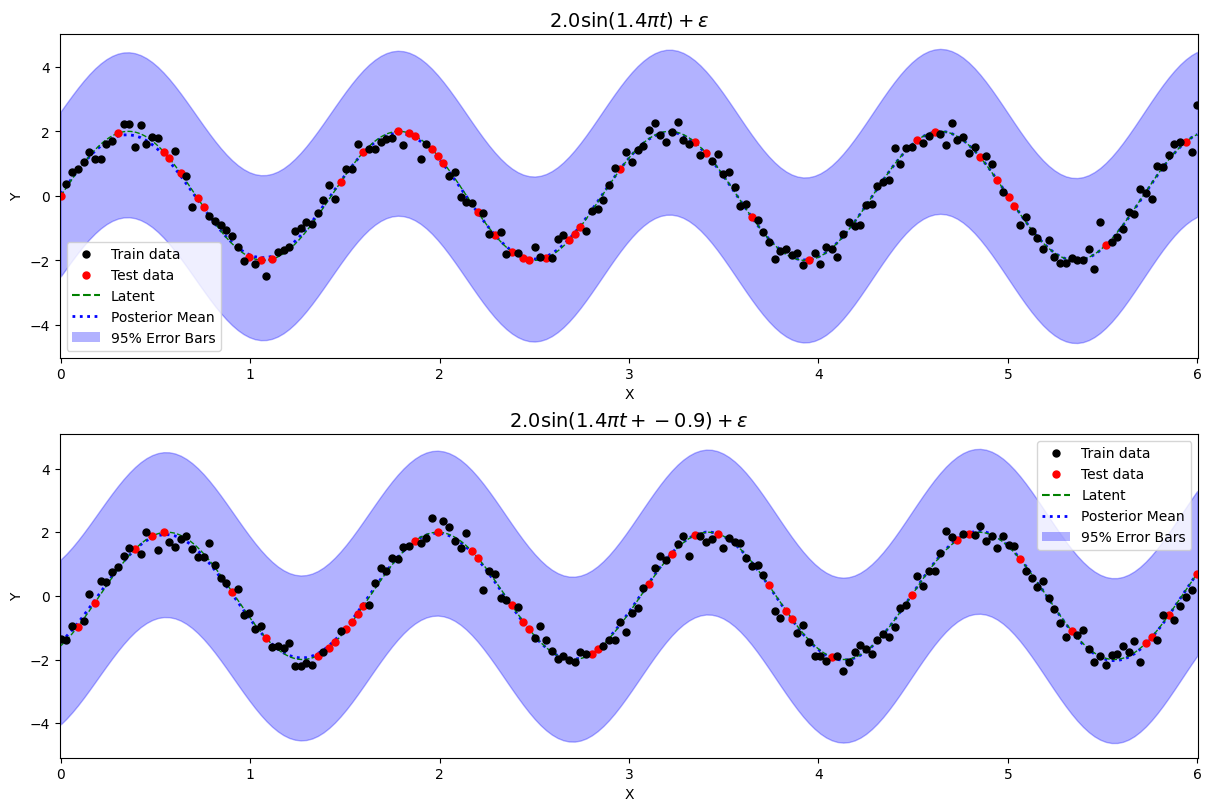

In [7]:
model3 = mogptk.MOSM(dataset1, Q=1)
model3.init_parameters(method='LS', iters=500)
model3.train(method='Adam', iters=1000, plot=True, error='MAE', verbose=True);
model3.plot_spectrum(title='PSD of trained model');
model3.plot_prediction();
model3.print_parameters()

### Retrain with delay fixed at zero

Starting optimization using Adam
‣ Model: Exact
  ‣ Kernel: MultiOutputSpectralMixtureKernel
  ‣ Likelihood: GaussianLikelihood
‣ Channels: 2
‣ Parameters: 10
‣ Training points: 320
‣ Iterations: 1000
     0/1000   0:00:00  loss=     442.269  error=    0.371005 (warmup)
  1000/1000   0:00:08  loss=     393.914  error=   0.0373808
Optimization finished in 8.327 seconds


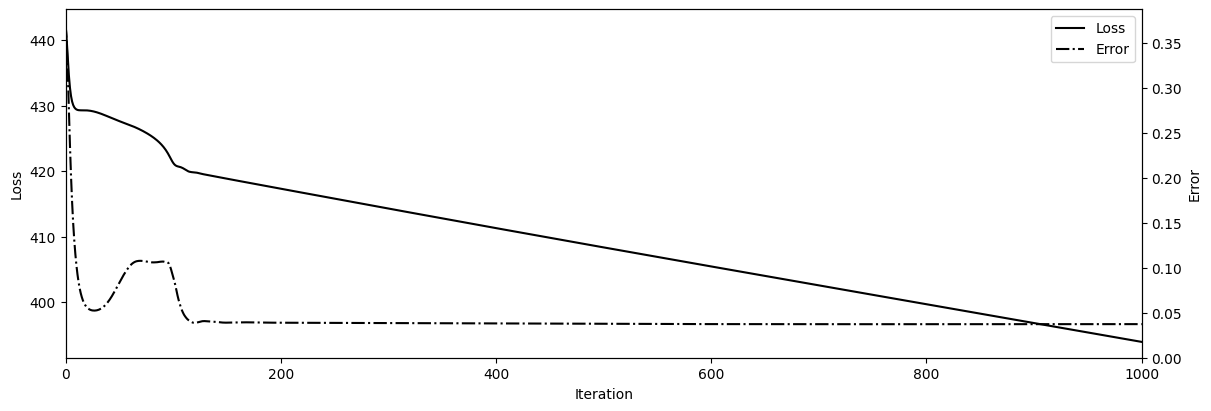

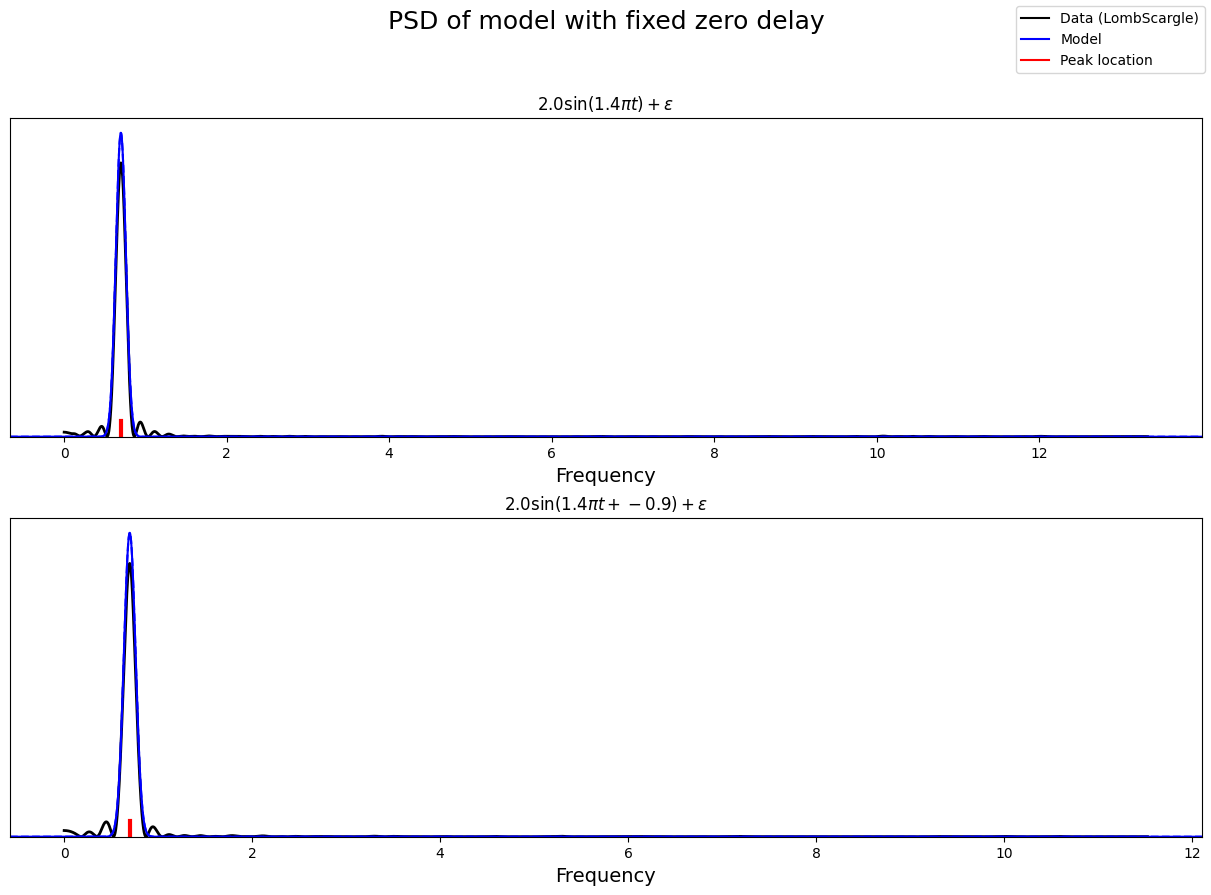

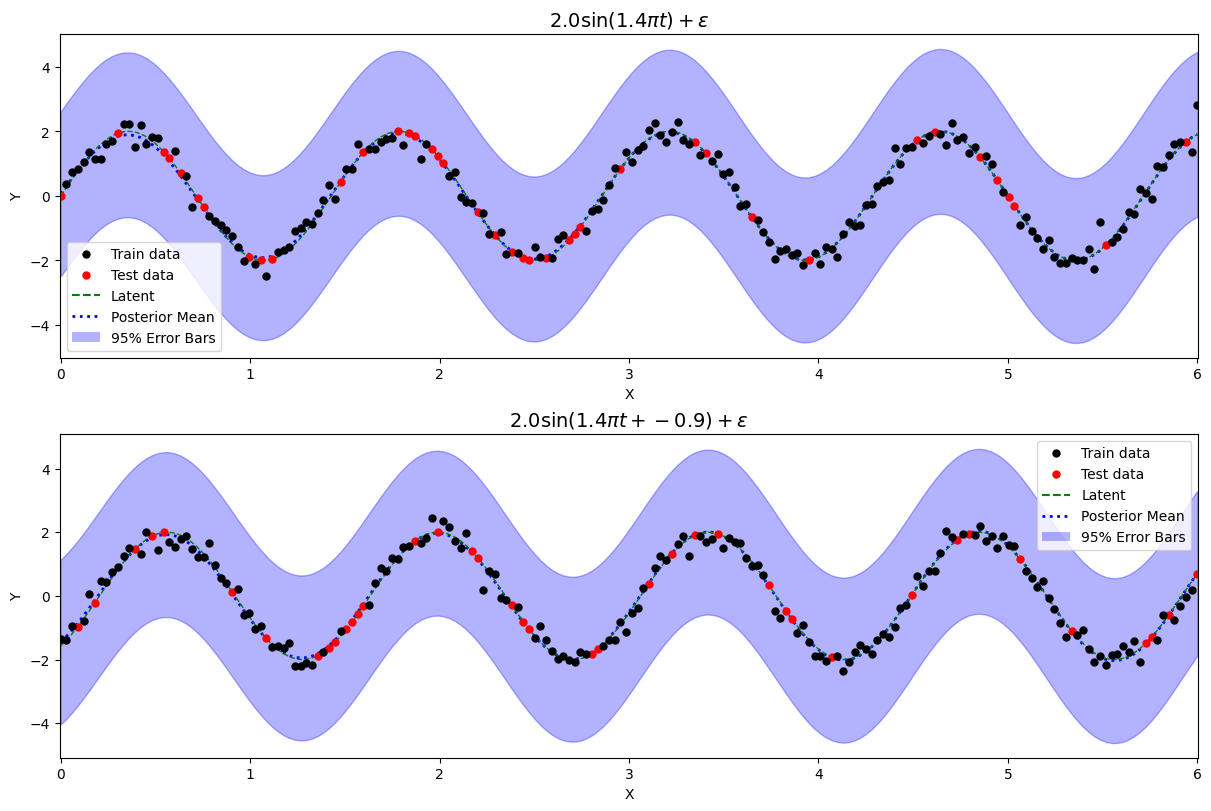

In [8]:
model4 = mogptk.MOSM(dataset1, Q=1)
model4.gpr.kernel.delay.assign(np.zeros((2,1)), lower=0, upper=0, train=False)
model4.init_parameters(method='LS', iters=500)
model4.train(method='Adam', iters=1000, plot=True, error='MAE', verbose=True);
model4.plot_spectrum(title='PSD of model with fixed zero delay');
model4.plot_prediction();

### Retrain with phase shift set at zero

Starting optimization using Adam
‣ Model: Exact
  ‣ Kernel: MultiOutputSpectralMixtureKernel
  ‣ Likelihood: GaussianLikelihood
‣ Channels: 2
‣ Parameters: 10
‣ Training points: 320
‣ Iterations: 1000
     0/1000   0:00:00  loss=     442.269  error=    0.371005 (warmup)
  1000/1000   0:00:07  loss=      393.91  error=    0.037112
Optimization finished in 7.332 seconds


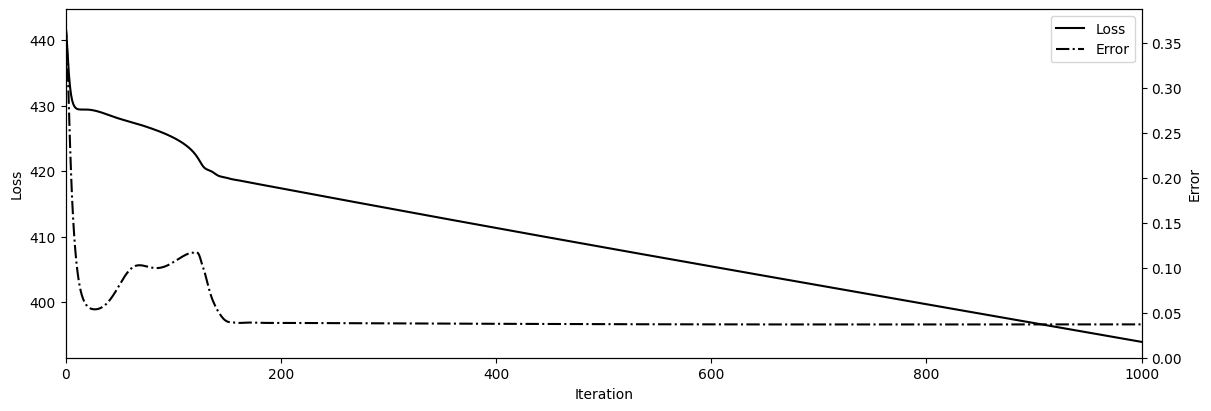

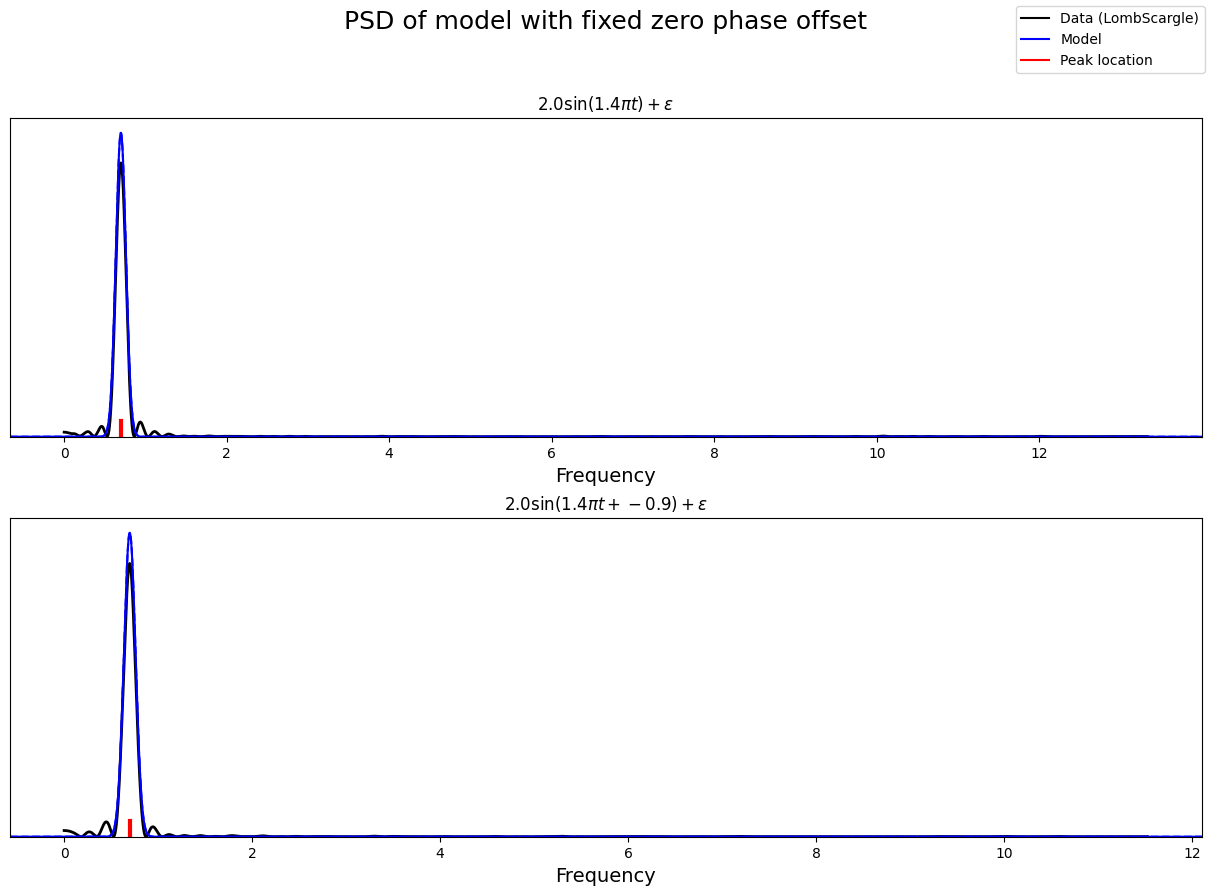

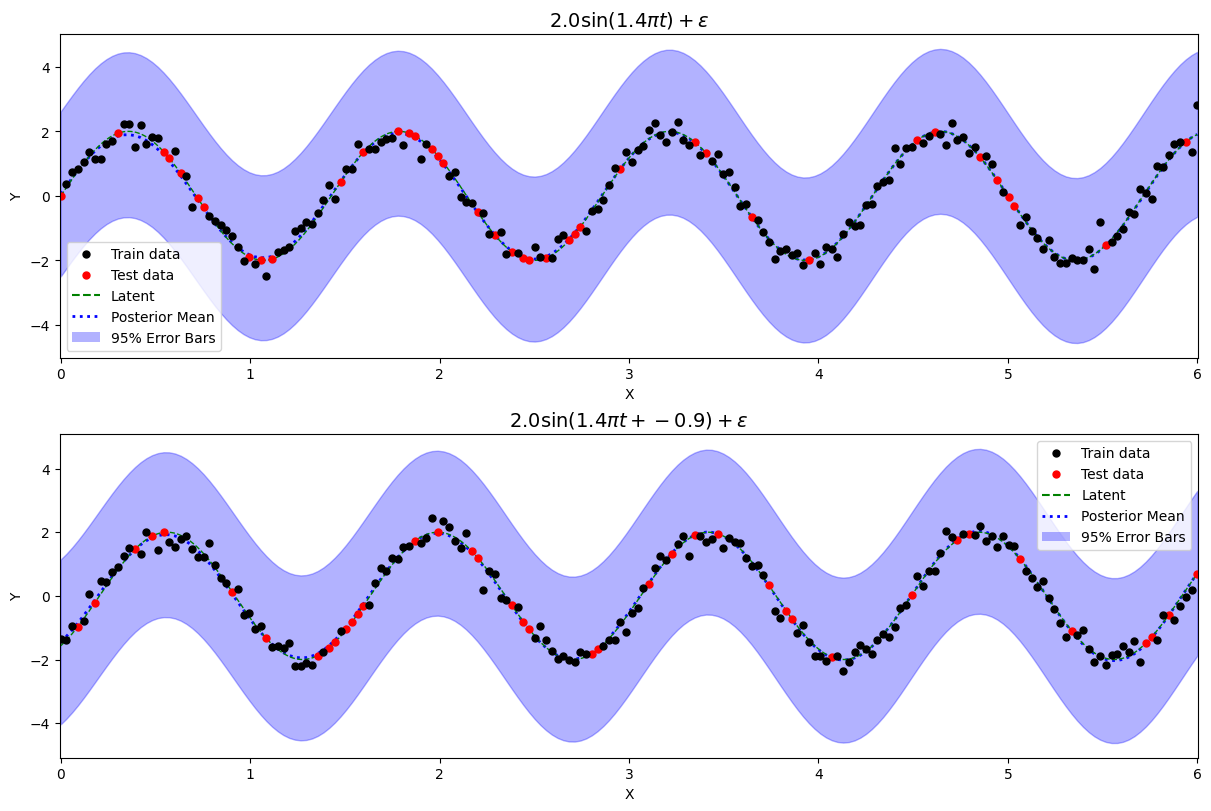

In [9]:
model5 = mogptk.MOSM(dataset1, Q=1)
model5.gpr.kernel.phase.assign(np.zeros((2,1)), lower=0, upper=0, train=False)
model5.init_parameters(method='LS', iters=500)
model5.train(method='Adam', iters=1000, plot=True, error='MAE', verbose=True);
model5.plot_spectrum(title='PSD of model with fixed zero phase offset');
model5.plot_prediction();

## Check results

In [10]:
(phase_shift/omega) / 2

-0.10231389198764701

In [11]:
model4.print_parameters()

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[18.77505733] [19.02752405]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 16.583333333333627]",[[[0.6992769 ]] [[0.69925524]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.00381148]] [[0.00381316]]]
MultiOutputSpectralMixtureKernel.delay,fixed,[[[0.]] [[0.]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[ 0.07110825] [-0.07110825]]
GaussianLikelihood.scale,"[1e-08, ∞)",[1.27877931 1.29535445]


In [12]:
model5.print_parameters()

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[18.76707025] [19.03517139]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 16.583333333333627]",[[[0.69934839]] [[0.6993265 ]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.00381036]] [[0.00381176]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[ 0.10171415]] [[-0.10171415]]]
MultiOutputSpectralMixtureKernel.phase,fixed,[[0.] [0.]]
GaussianLikelihood.scale,"[1e-08, ∞)",[1.2787247 1.29529508]


We find that the **delay** parameter estimate is half of the expected delay given the synthetic ground truth.

### Correlation between bands

array([[1.        , 0.59240001],
       [0.59240001, 1.        ]])

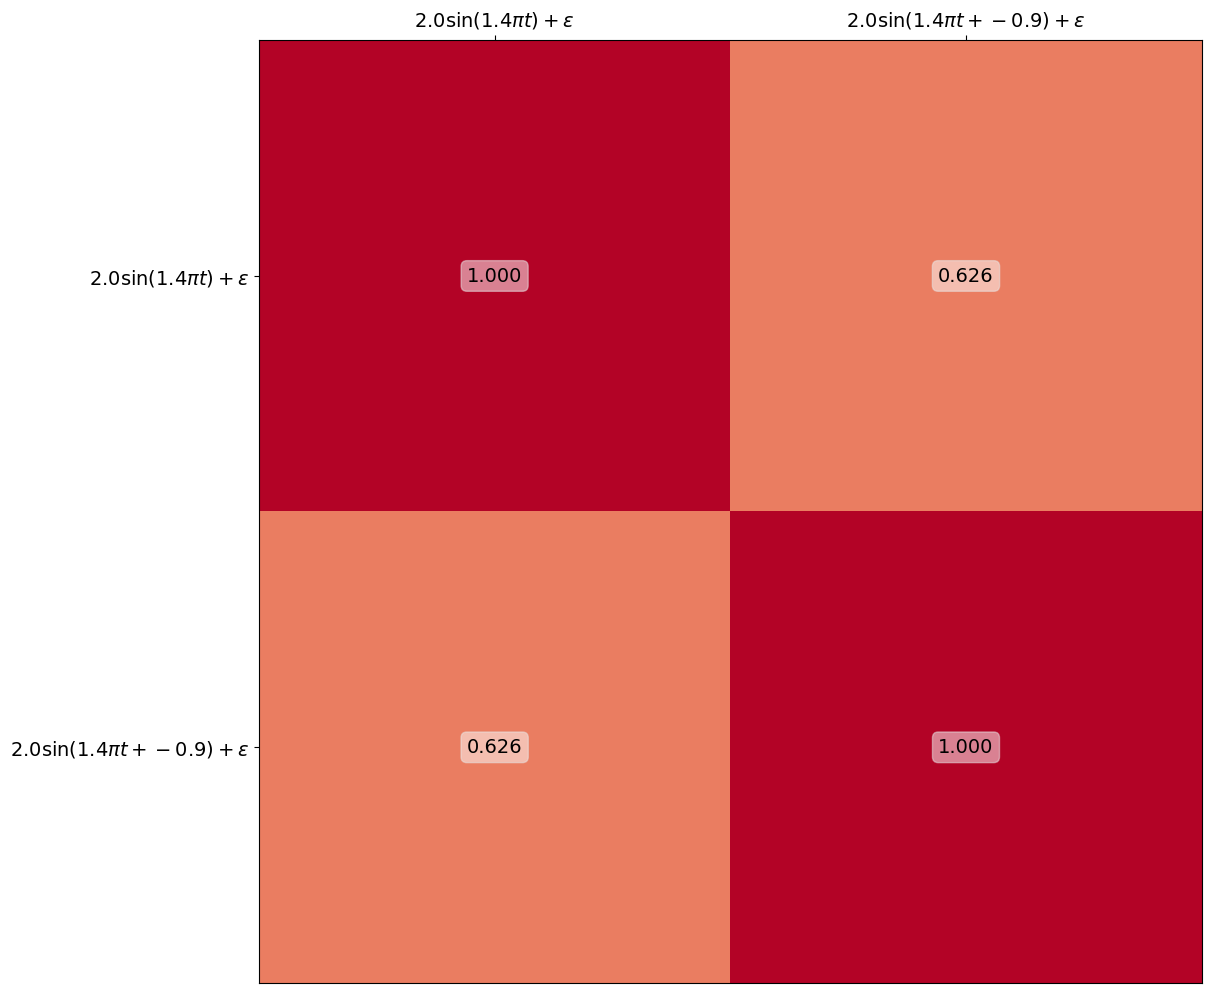

In [13]:
model5.plot_correlation();
np.corrcoef(y1, y2)

## 